# Z15 OV5640 摄像头采集示例

依次运行下面的代码格。camera_capture.bit 和 camera_capture.hwh 需要与本 Notebook 放在同一目录。

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from pynq import Overlay, allocate, MMIO

bitfile = os.path.join(os.getcwd(), 'camera_capture.bit')
overlay = Overlay(bitfile, download=True)
print('Overlay加载成功：', overlay.is_loaded())
print('可用IP：', list(overlay.ip_dict.keys()))

Overlay加载成功： True
可用IP： ['vdma', 'ps7']


In [2]:
WIDTH = 640
HEIGHT = 480
BYTES_PER_PIXEL = 2

frame = allocate(shape=(HEIGHT, WIDTH), dtype=np.uint16)
info = overlay.ip_dict['vdma']
vdma = MMIO(info['phys_addr'], info['addr_range'])
print('缓冲区地址：', hex(frame.physical_address))

缓冲区地址： 0x38100000


In [3]:
def take_photo(save_name=None):
    frame[:] = 0
    frame.flush()

    vdma.write(0x30, 0x04)
    time.sleep(0.2)
    vdma.write(0x30, 0x03)
    vdma.write(0xAC, frame.physical_address)
    vdma.write(0xA8, WIDTH * BYTES_PER_PIXEL)
    vdma.write(0xA4, WIDTH * BYTES_PER_PIXEL)
    vdma.write(0xA0, HEIGHT)

    time.sleep(1)
    status = vdma.read(0x34)
    vdma.write(0x30, 0x00)
    time.sleep(0.2)
    frame.invalidate()

    raw = np.array(frame, copy=True)
    r = (((raw >> 11) & 0x1F) * 255 // 31).astype(np.uint8)
    g = (((raw >> 5) & 0x3F) * 255 // 63).astype(np.uint8)
    b = ((raw & 0x1F) * 255 // 31).astype(np.uint8)
    image = np.dstack((r, g, b))

    if save_name:
        from PIL import Image
        Image.fromarray(image).save(save_name)
        print('已保存：', save_name)

    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    print('VDMA状态：', hex(status))
    return image

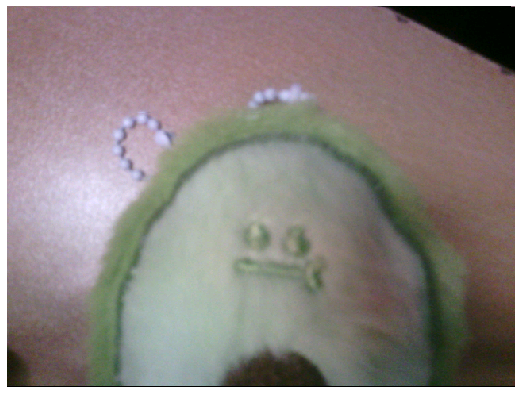

VDMA状态： 0x1d890


In [4]:
final_photo = take_photo()